# Loading Libraries/Modules

In [1]:
import torch
from torch import nn
from torch import optim as optim
from torch.nn import functional as F

import sys
sys.path.insert(1, 'helpers')
from dlc_practical_prologue import *
from helpers import *

%load_ext autoreload
%autoreload 2

# Convolutional Net

In [2]:
# 0.957/ 0.822 after 25 epochs, 1 round

class LinRecombNet(nn.Module):
    
    def __init__(self):
        super(LinRecombNet, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5,stride=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3,stride=1)
        self.conv3 = nn.Conv2d(in_channels=64,out_channels=32, kernel_size=5,stride=1)
        self.conv4 = nn.Conv2d(in_channels=32,out_channels=10,kernel_size=2,stride=2)
        self.fc1 = nn.Linear(40,2)
        
        #self.maxpool1 = nn.MaxPool2d(kernel_size=2,stride=2,padding=0)
        #self.maxpool2 = nn.MaxPool2d(kernel_size=2,stride=2,padding=1)
        
    def forward(self, x):
        #Branch 1
        x1 = F.relu(self.conv1(x[:,0:1]))
        x1 = F.relu(self.conv2(x1))
        x1 = F.relu(self.conv3(x1))
        x1 = F.relu(self.conv4(x1))
        #Branch 2
        x2 = F.relu(self.conv1(x[:,1:2]))
        x2 = F.relu(self.conv2(x2))
        x2 = F.relu(self.conv3(x2))
        x2 = F.relu(self.conv4(x2))
        
        #Recombination
        x = F.relu(self.fc1(x1.view(-1,40)-x2.view(-1,40)))
        
        return x, None

In [3]:
# 0.942 / 0.836 after 15 epochs, 3 rounds
class NonlinRecombNet(nn.Module):
    def __init__(self):
        super(NonlinRecombNet, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=4,stride=1,padding=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2,stride=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=128, kernel_size=1,stride=1)
        self.maxpool2 = nn.MaxPool2d(kernel_size=3,stride=1)
        self.conv3 = nn.Conv2d(in_channels=128,out_channels=64, kernel_size=1,stride=1)
        self.conv4 = nn.Conv2d(in_channels=64,out_channels=32,kernel_size=1,stride=1)
        self.conv = nn.Conv2d(in_channels=32,out_channels=10,kernel_size=1,stride=1)
        
        self.conv5 = nn.Conv2d(in_channels=20,out_channels=64,kernel_size=3)
        self.maxpool5 = nn.MaxPool2d(kernel_size=3,stride=1)
        self.conv6 = nn.Conv2d(in_channels=64,out_channels=32,kernel_size=3)
        self.conv7 = nn.Conv2d(in_channels=32,out_channels=16,kernel_size=3)
        self.maxpool7 = nn.MaxPool2d(kernel_size=2,stride=2)
        self.fct = nn.Linear(16,2)
        
        
    def forward(self, x):
        #Branch 1
        x1 = F.relu(self.conv1(x[:,0:1])) #32x13x13
        x1 = self.maxpool1(x1) #32x12x12
        x1 = F.relu(self.conv2(x1)) #128x12x12
        x1 = self.maxpool2(x1) #128x10x10
        x1 = F.relu(self.conv3(x1)) #64x10x10
        x1 = F.relu(self.conv4(x1)) #32x10x10
        x1 = F.relu(self.conv(x1)) #10x10x10
        
        #Branch 2
        x2 = F.relu(self.conv1(x[:,1:2]))
        x2 = self.maxpool1(x2)
        x2 = F.relu(self.conv2(x2))
        x2 = self.maxpool2(x2)
        x2 = F.relu(self.conv3(x2))
        x2 = F.relu(self.conv4(x2))
        x2 = F.relu(self.conv(x2))
        
        #Recombination
        x = F.relu(torch.cat((x1,x2), dim=1)) #20x10x10
        x = F.relu(self.conv5(x)) #64x8x8
        x = F.relu(self.maxpool5(x)) #64x6x6
        x = F.relu(self.conv6(x)) #32x4x4
        x = F.relu(self.conv7(x)) #16x2x2
        x = F.relu(self.maxpool7(x))
        x = self.fct(x.view(-1,16))

        return x, None

# Training helpers

In [4]:
# Train a model, print the results and return the train and validation loss.
def train_model(model, rounds, nb_epochs=100, batch_size=100, validation=True, verbose=False):
                
    nb_epochs_shown = 10
    
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr = 1e-3)
    
    # tensors for averaging over the rounds
    times = torch.zeros(rounds)
    train_acc = torch.zeros(rounds)
    test_acc = torch.zeros(rounds)
    train_loss = torch.zeros(rounds, nb_epochs + 1)
    validation_loss = torch.zeros(rounds, nb_epochs + 1)
    
    for r in range(rounds):
        
        # new data
        train_input, train_target, train_classes, val_input, val_target, val_classes = generate_pair_sets(nb=1000)
        
        # reset weights
        model.apply(weight_reset) 
        
        t0 = time.time()

        for e in range(nb_epochs):
            
            # store the train and validation loss for each epoch and round 
            if validation:
                model.train(False) # deactivate dropout
                train_loss[r,e] = criterion(model(train_input)[0], train_target)
                validation_loss[r,e] = criterion(model(val_input)[0], val_target)
                model.train(True) # activate dropout
            
            # updating the model
            for input, targets, classes in zip(train_input.split(batch_size), 
                                               train_target.split(batch_size), 
                                               train_classes.split(batch_size)):
                
                output = model(input)
                loss = criterion(output[0], targets)
                if output[1] is not None:
                    c_aux = 0
                    c_final = 1
                    loss_aux1 = criterion(output[1][:, :10], classes[:,0])
                    loss_aux2 = criterion(output[1][:, 10:], classes[:,1])
                    loss = c_final * loss + c_aux * (loss_aux1 + loss_aux2)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # print the loss for a given number of epochs - used for direct feedback
            if verbose:
                if((e + 1) % int(nb_epochs / nb_epochs_shown) == 0):
                    print("Epoch {} | Train loss : {}".format(e+1, loss))
                    
        # final loss            
        if validation:
            model.train(False) # deactivate dropout
            train_loss[r,nb_epochs] = criterion(model(train_input)[0], train_target)
            validation_loss[r,nb_epochs] = criterion(model(val_input)[0], val_target)
            model.train(True) # activate dropout

        t1 = time.time()
        
        times[r] = t1-t0
        train_acc[r] = accuracy(model, train_input, train_target)
        test_acc[r] = accuracy(model, val_input, val_target)
        
        print('Round {} done.'.format(r))
        
    print('--------------')
    
    total_trained_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("Model : {} \n".format(model.__class__.__name__ ) + \
          "Number of trained parameters : {} \n".format(total_trained_params) + \
          "Size of mini-batches : {}\n".format(batch_size) + \
          "Averaged on {} rounds \n".format(rounds+1) + \
          "    Time for {} epochs : {:.2f}s\n".format(nb_epochs, times.mean().item()) + \
          "    Train accuracy : {:.3f} \n".format(train_acc.mean().item()) + \
          "    Test accuracy : {:.3f}".format(test_acc.mean().item()))
    
    return train_loss.detach().mean(dim=0), validation_loss.detach().mean(dim=0)

def accuracy(model, test_input, test_target):
    nb_samples = test_input.shape[0]
    model.train(False) # deactivate dropout
    output = model(test_input)[0]
    model.train(True) # activate dropout
    output_int = torch.zeros(nb_samples)
    for i in range(nb_samples):
        if output[i][0] <= output[i][1]: # first digit lesser or equal
            output_int[i] = 1
    nb_errors = (output_int - test_target).type(torch.BoolTensor).sum().item()
    return (nb_samples - nb_errors) / nb_samples

# Training

In [5]:
rounds = 3
model = NonlinRecombNet()
avg_train_loss, avg_val_loss = train_model(model, rounds,nb_epochs=15, validation=True, verbose=True)

Epoch 1 | Train loss : 0.6019083857536316
Epoch 2 | Train loss : 0.494396448135376
Epoch 3 | Train loss : 0.3418312072753906
Epoch 4 | Train loss : 0.3387506902217865
Epoch 5 | Train loss : 0.2982867658138275
Epoch 6 | Train loss : 0.2176918387413025
Epoch 7 | Train loss : 0.1824893206357956
Epoch 8 | Train loss : 0.1406203806400299
Epoch 9 | Train loss : 0.1145414412021637
Epoch 10 | Train loss : 0.08177647739648819
Epoch 11 | Train loss : 0.047684911638498306
Epoch 12 | Train loss : 0.08962354063987732
Epoch 13 | Train loss : 0.08461932837963104
Epoch 14 | Train loss : 0.05597970634698868
Epoch 15 | Train loss : 0.033038873225450516
Round 0 done.
Epoch 1 | Train loss : 0.6814531683921814
Epoch 2 | Train loss : 0.6329858303070068
Epoch 3 | Train loss : 0.5503889322280884
Epoch 4 | Train loss : 0.5484037399291992
Epoch 5 | Train loss : 0.482616662979126
Epoch 6 | Train loss : 0.4437938928604126
Epoch 7 | Train loss : 0.39228394627571106
Epoch 8 | Train loss : 0.393314391374588
Epoch 9 

# Visualization

In [7]:
import matplotlib.pyplot as plt
import numpy as np

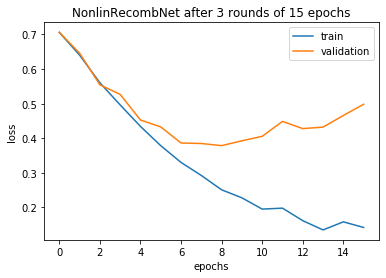

In [14]:
fig, ax = plt.subplots(figsize=(6,4))

plt.plot(avg_train_loss,label='train')
plt.plot(avg_val_loss, label='validation')

nb_epochs = avg_train_loss.shape[0]

ax.legend()
plt.title("{}".format(model.__class__.__name__ )+" after {} rounds".format(rounds)+" of {} epochs".format(nb_epochs-1))
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()